In [5]:
# 1. 환경 설정 및 라이브러리 임포트
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 설치된 나눔 폰트 적용
sys_fonts = fm.findSystemFonts(fontpaths=None, fontext='ttf')
for font_path in sys_fonts:
    if 'Nanum' in font_path:
        fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("✅ [Cell 1] 환경 설정, 라이브러리 임포트 및 드라이브 마운트 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ [Cell 1] 환경 설정, 라이브러리 임포트 및 드라이브 마운트 완료


In [6]:
def preprocess_youth_dataset(filepath, model_type='lr'):
    print("="*70)
    print("[Cell 2] 데이터 전처리 및 스케일링 수행")
    print("="*70)

    df = pd.read_csv(filepath, encoding='cp949')
    df.columns = df.columns.str.strip()

    df['Target'] = df['우울증상 유병 여부'].map({1: 0, 2: 1})
    y = df['Target']

    drop_cols = ['우울증상 유병 여부', 'Target', '최근 1년 소진(번아웃) 경험 여부']
    X = df.drop(columns=[col for col in drop_cols if col in df.columns])
    X = X.copy()

    if '경제활동상태' in X.columns:
        X['현재 근무 여부'] = X['경제활동상태'].apply(lambda x: 1 if x == 1 else 0)
    else:
        X['현재 근무 여부'] = 0

    ordinal_mappings = {
        '현재 흡연 여부': {4: 1, 3: 2, 2: 3, 1: 4},
        '최근 1년간 음주 빈도': {7: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6},
        '외식 또는 매식 빈도': {5: 0, 4: 1, 3: 2, 2: 3, 1: 4},
        '일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다': {5: 1, 4: 2, 3: 3, 2: 4, 1: 5},
        '정치에 대한 관심 정도': {4: 1, 3: 2, 2: 3, 1: 4},
        '외출 빈도': {8: 1, 7: 2, 6: 3, 5: 4, 4: 5, 3: 6, 2: 7, 1: 8},
        '주관적 계층 인식': {5: 1, 4: 2, 3: 3, 2: 4, 1: 5}
    }

    standard_ordinal_cols = [
        '연령별', '가구원수', '최종학력', '음주 정도', '평소 규칙적 운동 여부',
        '고용 계약 기간', '총 고용 예상 기간', '지난 주 일자리 종사자 수', '재직 기간(범위)'
    ]

    def apply_ordinal_transform(data):
        data = data.copy()
        if '정규근로시간 외 추가 근무' in data.columns:
            data['정규근로시간 외 추가 근무'] = data['정규근로시간 외 추가 근무'].map(
                {6: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 7: 1}
            ).fillna(0)

        if '정규 근로일 외 휴일 근무 횟수' in data.columns:
            data['정규 근로일 외 휴일 근무 횟수'] = data['정규 근로일 외 휴일 근무 횟수'].map(
                {0: 1, 1: 2, 2: 3}
            ).fillna(0)

        for col, mapping in ordinal_mappings.items():
            if col in data.columns:
                data[col] = data[col].fillna(0).map(mapping).fillna(0)

        for col in standard_ordinal_cols:
            if col in data.columns:
                data[col] = data[col].fillna(0)
        return data

    X = apply_ordinal_transform(X)

    nominal_cols = [
        '성별', '지역별', '장애여부','귀하의 현재 재학 상태를 응답해 주십시오.', '(복수 응답) 가구유형(1)',
        '국민기초생활보장제도(또는 맞춤형 급여) 수급 여부 및 경험', '돌봄 필요 가구원 유무', '혼인 상태',
        '부모 동거 여부', '공공 임대 주택 거주 경험', '현재 주거 점유 형태', '최근 1달 동안 같이 식사한 사람',
        '경제활동상태', '지난 주 수입을 목적으로 1시간 이상 일한 경험', '지난 주 종사상 지위',
        '고용 계약 기간 유무', '주휴 수당 수급 여부', '정규근로시간 외 추가 근무 시 추가 수당 수급 여부',
        '정규근로일 외 휴일 근무 시 추가 수당 수급 여부',
        '장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)',
        '대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 가족^ 친척',
        '대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 – 이외',
        '현재 연애 여부(유배우 포함)', '향후 결혼 계획(유배우 포함)',
        '금융 채무 불이행자(신용불량자)에 해당 여부', '현재 근무 여부'
    ]

    valid_nominal_cols = [col for col in nominal_cols if col in X.columns]
    for col in valid_nominal_cols:
        X[col] = X[col].fillna('해당없음').astype(str)

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_ohe = pd.DataFrame(
        ohe.fit_transform(X[valid_nominal_cols]),
        columns=ohe.get_feature_names_out(valid_nominal_cols),
        index=X.index
    )
    ohe_cols = list(X_ohe.columns)

    robust_cols = ['청년 연간소득 - 총 소득', '청년 기준 부채 총액', '청년 기준 재산총액']
    standard_cols = ['월 평균 총생활비']

    for col in robust_cols + standard_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0)
            X[col] = np.log1p(X[col])

    X_non_nominal = X.drop(columns=valid_nominal_cols, errors='ignore')
    X_final = pd.concat([X_non_nominal, X_ohe], axis=1)

    if model_type == 'lr':
        valid_robust_cols = [col for col in robust_cols if col in X_final.columns]
        if valid_robust_cols:
            r_scaler = RobustScaler()
            X_final[valid_robust_cols] = r_scaler.fit_transform(X_final[valid_robust_cols])

        valid_standard_cols = [
            col for col in standard_cols + standard_ordinal_cols + list(ordinal_mappings.keys())
            if col in X_final.columns and col not in valid_robust_cols and col not in ohe_cols
        ]
        if valid_standard_cols:
            s_scaler = StandardScaler()
            X_final[valid_standard_cols] = s_scaler.fit_transform(X_final[valid_standard_cols])

    print(f"✅ 최종 데이터 형태 - X: {X_final.shape}, y: {y.shape}")
    return X_final, y

print("✅ [Cell 2] 전처리 함수 정의 완료")

✅ [Cell 2] 전처리 함수 정의 완료


In [7]:
# 💡 본인의 구글 드라이브 내 CSV 파일 경로로 반드시 수정해 주세요.
filepath = '/content/drive/MyDrive/2024_청년삶실태조사.csv'

# 클러스터링(거리 기반)을 위해 스케일링이 포함된 'lr' 모드로 데이터를 로드합니다.
X_scaled, y_target = preprocess_youth_dataset(filepath, model_type='lr')

[Cell 2] 데이터 전처리 및 스케일링 수행
✅ 최종 데이터 형태 - X: (15098, 124), y: (15098,)


[STEP 1] 핵심 Feature 10개 추출
군집화 적용 피처 수: 13개 차원 (OHE 파생변수 포함)

[STEP 2] 최적 K 탐색


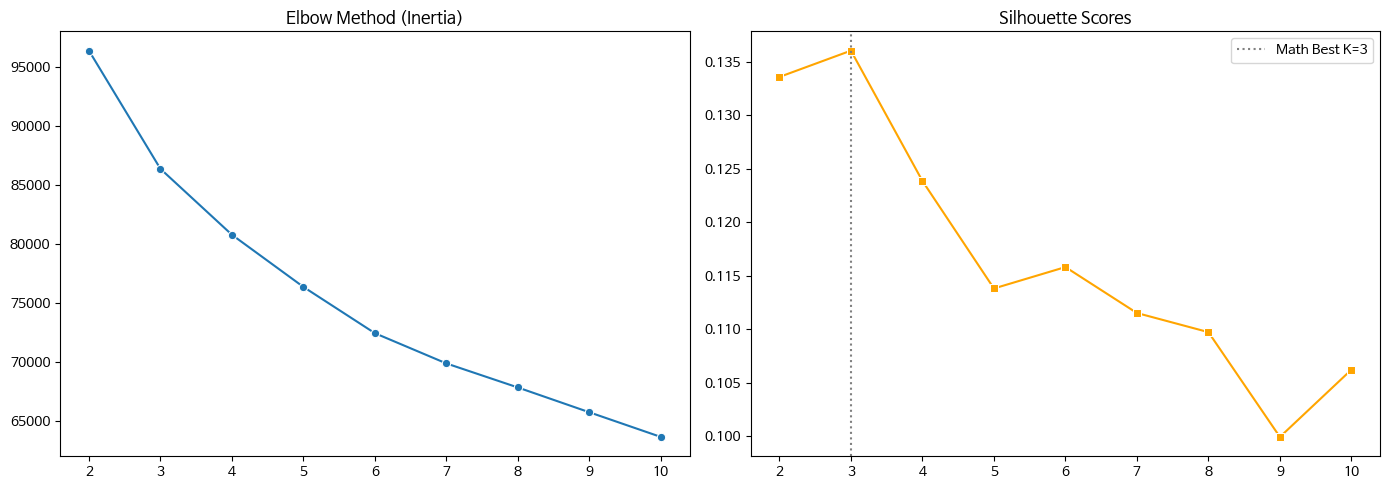

💡 [선정 결과] 최적 K: 3(해당 K의 Silhouette Score: 0.1360)
[STEP 3] 최종 선택된 K=3 KMeans 학습 및 군집 생성
🚨 [STEP 4] High-Risk Cluster 식별 (우울증상 비율 기준)


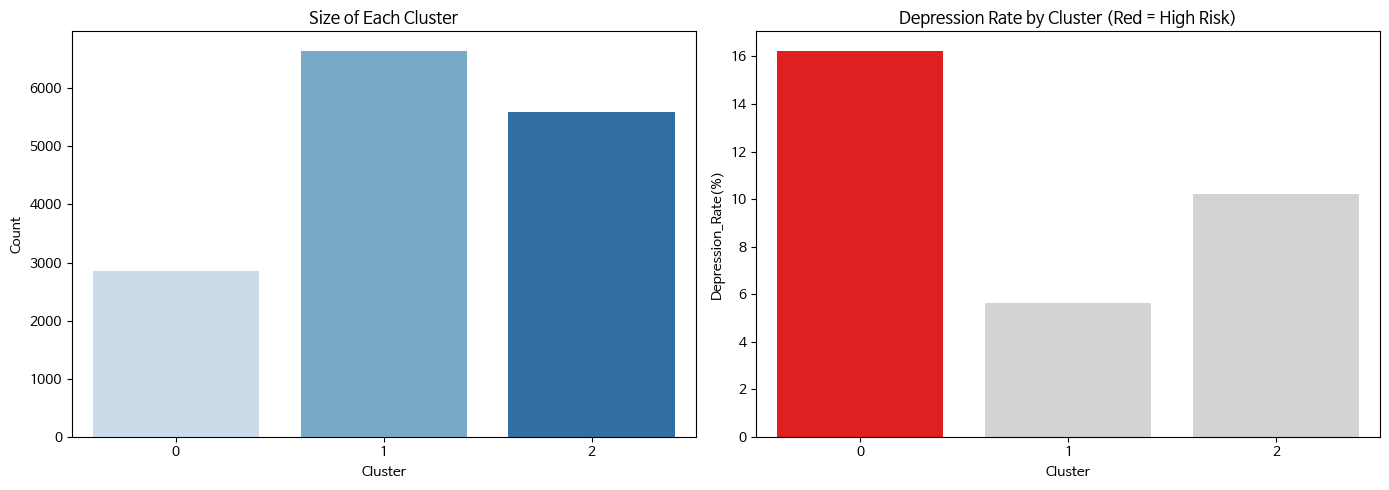


 Cluster  Count  Depression_Rate(%)
       0   2856           16.246499
       1   6650            5.609023
       2   5592           10.193133

우울증상 유병률이 가장 높은 **Cluster 0** (16.25%)를 High-Risk 집단으로 지정합니다.

[STEP 5] 데이터 연산 중: 전수 변수 평균/비율 차이 계산 (백엔드 작업)
모든 변수 비교 연산 완료. 다음 단계에서 결과를 시각화합니다.

[STEP 6] 고위험군 주요 특성(Top 2) 분포 시각화


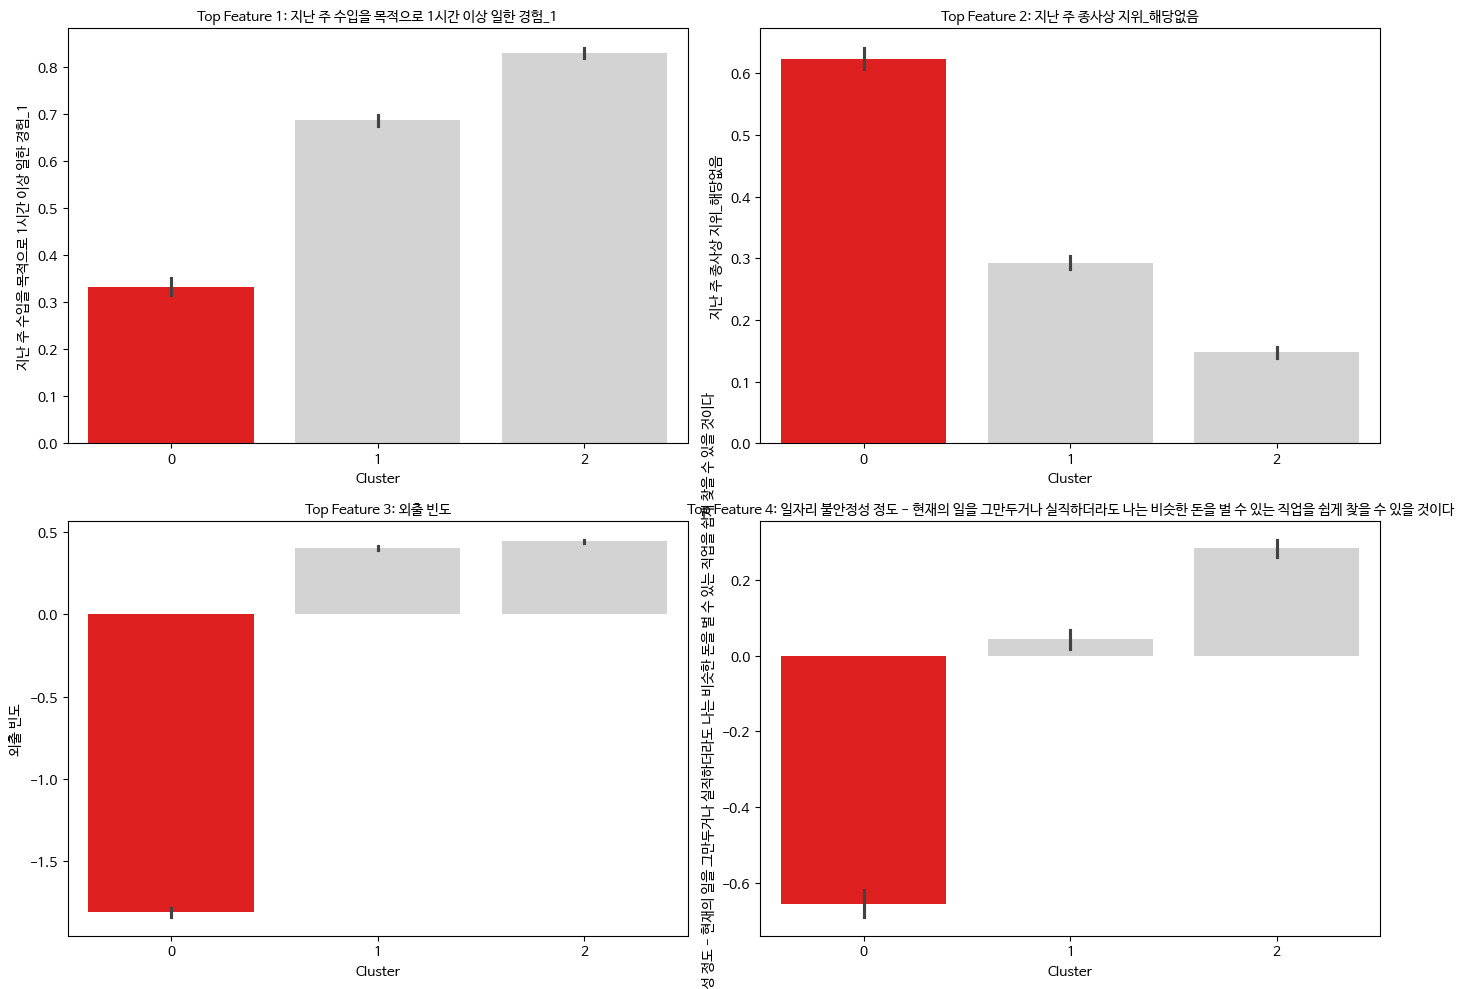

[최종 결론] Cluster 0 고위험군의 결정적 특성 핵심 Top 10
 - [외출 빈도] (평균 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다] (평균 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [재직 기간(범위)] (평균 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [지난 주 일자리 종사자 수] (평균 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [청년 연간소득 - 총 소득] (평균 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [지난 주 수입을 목적으로 1시간 이상 일한 경험_1] (비율 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [지난 주 종사상 지위_해당없음] (비율 차이): 일반 집단 대비 상대적으로 높음/많음
 - [고용 계약 기간 유무_해당없음] (비율 차이): 일반 집단 대비 상대적으로 높음/많음
 - [장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)_2.0] (비율 차이): 일반 집단 대비 상대적으로 낮음/적음
 - [경제활동상태_1] (비율 차이): 일반 집단 대비 상대적으로 낮음/적음


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_clustering_pipeline(X_all, y_all, feature_cols):
    print("="*70)
    print("[STEP 1] 핵심 Feature 10개 추출")
    print("="*70)

    selected_cols = []
    for base_feat in feature_cols:
        if "이외" in base_feat:
            matched = [col for col in X_all.columns if "교류하는 사람의 유무" in col and "이외" in col]
        else:
            matched = [col for col in X_all.columns if base_feat in col]
        selected_cols.extend(matched)

    selected_cols = list(set(selected_cols))
    X_cluster = X_all[selected_cols]

    print(f"군집화 적용 피처 수: {len(selected_cols)}개 차원 (OHE 파생변수 포함)\n")

    print("="*70)
    print("[STEP 2] 최적 K 탐색")
    print("="*70)

    inertias, silhouettes = [], []
    # 해석력을 고려하여 K=2부터 K=10까지 탐색
    K_range = range(2, 11)

    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_cluster)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_cluster, labels))

    best_k = K_range[np.argmax(silhouettes)]

    fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
    sns.lineplot(x=K_range, y=inertias, marker='o', ax=axes1[0])
    axes1[0].set_title('Elbow Method (Inertia)')
    sns.lineplot(x=K_range, y=silhouettes, marker='s', color='orange', ax=axes1[1])
    axes1[1].set_title('Silhouette Scores')

    axes1[1].axvline(best_k, color='gray', linestyle=':', label=f'Math Best K={best_k}')
    axes1[1].legend()
    plt.tight_layout()
    plt.show()

    print(f"[선정 결과] 최적 K: {best_k}(해당 K의 Silhouette Score: {max(silhouettes):.4f})")


    print("="*70)
    print(f"[STEP 3] 최종 선택된 K={best_k} KMeans 학습 및 군집 생성")
    print("="*70)

    best_km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    cluster_labels = best_km.fit_predict(X_cluster)

    print("="*70)
    print("[STEP 4] High-Risk Cluster 식별 (우울증상 비율 기준)")
    print("="*70)

    df_full = X_all.copy()
    df_full['Cluster'] = cluster_labels
    df_full['Target'] = y_all.values

    cluster_stats = df_full.groupby('Cluster')['Target'].agg(['count', 'mean']).reset_index()
    cluster_stats.rename(columns={'count': 'Count', 'mean': 'Depression_Rate'}, inplace=True)
    cluster_stats['Depression_Rate(%)'] = cluster_stats['Depression_Rate'] * 100

    high_risk_cluster = cluster_stats.loc[cluster_stats['Depression_Rate'].idxmax(), 'Cluster']
    high_risk_rate = cluster_stats['Depression_Rate(%)'].max()

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x='Cluster', y='Count', data=cluster_stats, ax=axes2[0], palette='Blues')
    axes2[0].set_title('Size of Each Cluster')
    colors = ['red' if c == high_risk_cluster else 'lightgray' for c in cluster_stats['Cluster']]
    sns.barplot(x='Cluster', y='Depression_Rate(%)', data=cluster_stats, ax=axes2[1], palette=colors)
    axes2[1].set_title('Depression Rate by Cluster (Red = High Risk)')
    plt.tight_layout()
    plt.show()

    print("\n" + cluster_stats[['Cluster', 'Count', 'Depression_Rate(%)']].to_string(index=False))
    print(f"\n우울증상 유병률이 가장 높은 **Cluster {high_risk_cluster}** ({high_risk_rate:.2f}%)를 High-Risk 집단으로 지정합니다.\n")

    print("="*70)
    print("[STEP 5] 데이터 연산 중: 전수 변수 평균/비율 차이 계산 (백엔드 작업)")
    print("="*70)

    df_high_risk = df_full[df_full['Cluster'] == high_risk_cluster]
    df_others = df_full[df_full['Cluster'] != high_risk_cluster]
    results = []

    for col in X_all.columns:
        if col in ['Cluster', 'Target']: continue

        high_risk_mean = df_high_risk[col].mean()
        others_mean = df_others[col].mean()
        diff = high_risk_mean - others_mean

        # OHE 변수(nunique <= 2)의 평균은 범주별 비율을 의미함
        if df_full[col].nunique() <= 2:
            feat_type = '비율 차이'
        else:
            feat_type = '평균 차이'

        results.append([col, feat_type, high_risk_mean, others_mean, diff])

    res_df = pd.DataFrame(results, columns=['Feature', 'Type', 'HighRisk_Mean', 'Others_Mean', 'Difference'])
    res_df['Abs_Diff'] = res_df['Difference'].abs()

    # 완벽히 대칭되는 OHE 파생변수 중복 제거 (절대값이 같은 경우 1개만 남김)
    # 제거하지않으면 지난주수입목적노동_1과 지난주수입목적노동_2가 둘 다 포함됨
    res_df['Abs_Diff_Rounded'] = res_df['Abs_Diff'].round(6)
    res_df = res_df.drop_duplicates(subset=['Abs_Diff_Rounded']).drop(columns=['Abs_Diff_Rounded'])

    # 유형별 Top 5 추출 후 병합
    cat_df = res_df[res_df['Type'] == '비율 차이'].sort_values(by='Abs_Diff', ascending=False)
    num_df = res_df[res_df['Type'] == '평균 차이'].sort_values(by='Abs_Diff', ascending=False)

    # 두 범주 합쳐서 최종 10개 구성
    sig_df = pd.concat([cat_df.head(5), num_df.head(5)]).sort_values(by='Abs_Diff', ascending=False)

    print("모든 변수 비교 연산 완료. 다음 단계에서 결과를 시각화합니다.\n")

    print("="*70)
    print("[STEP 6] 고위험군 주요 특성(Top 2) 분포 시각화")
    print("="*70)

    # 각 유형별 Top 2 추출 (총 4개)
    top_cat = cat_df['Feature'].head(2).tolist()
    top_num = num_df['Feature'].head(2).tolist()
    top_features = top_cat + top_num

    # 4개 그래프를 위해 2x2 서브플롯으로 변경
    fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
    axes3 = axes3.flatten()

    for i, feature in enumerate(top_features):
        # 비율(OHE 평균)과 Ordinal/Numeric 모두 barplot(막대그래프)으로 통일하여 시각화
        sns.barplot(x='Cluster', y=feature, data=df_full, ax=axes3[i], palette=colors)
        axes3[i].set_title(f'Top Feature {i+1}: {feature}', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("="*70)
    print(f"[최종 결론] Cluster {high_risk_cluster} 고위험군의 결정적 특성 핵심 Top 10")
    print("="*70)

    for idx, row in sig_df.iterrows():
        trend = "상대적으로 높음/많음" if row['Difference'] > 0 else "상대적으로 낮음/적음"
        print(f" - [{row['Feature']}] ({row['Type']}): 일반 집단 대비 {trend}")

# 선정된 핵심 10개 피처 리스트
selected_features = [
    "평소 본인에 대한 건강 인식", "외출 빈도", "청년 기준 부채 총액", "정치에 대한 관심 정도",
    "가구원수", "주관적 계층 인식", "외식 또는 매식 빈도", "성별",
    "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 이외", "최근 1달 동안 같이 식사한 사람"
]

# 함수 실행
run_clustering_pipeline(X_scaled, y_target, selected_features)